In [27]:
from pathlib import Path
import yaml
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

In [28]:
# get path to project root directory
project_root = Path.cwd().parents[0]

# build path to yaml config file
config_path = project_root / "configs"/"paths.yaml"

In [29]:
with open(config_path) as f:
    paths = yaml.safe_load(f)
paths

{'data': {'external': 'data/external',
  'raw': 'data/raw',
  'processed': 'data/processed',
  'results': 'results',
  'imagery': 'data/imagery'},
 'outputs': {'dynamic_maps': 'outputs/maps/dynamic',
  'static_maps': 'output/maps/static',
  'figures': 'output/figures',
  'tables': 'outputs/tables'},
 'imagery': {'nakivale_sample': 'data/imagery/nakivale_sample'}}

In [30]:
# Access imagery root directory
imagery_root = project_root / paths["imagery"]["nakivale_sample"]

# sample grid cell
grid_cell_id = 90

# Access grid cell 208 folder
chip_dir = imagery_root / f'{grid_cell_id}'

print(chip_dir)

c:\Users\Zachary\phd_classes\uganda\data\imagery\nakivale_sample\90


In [31]:
chips = sorted([p for p in chip_dir.iterdir() if p.suffix == ".tif"])
chips

[WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/90/90_15JUN15083002-M2AS-507744471100_01_P002.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/90/90_16AUG14082440-M2AS-507744472100_01_P002.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/90/90_16AUG14082440-P2AS-507744472100_01_P002.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/90/90_16DEC19083716-P2AS-507744475100_01_P001.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/90/90_16DEC19083717-M2AS-507744475100_01_P002.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/90/90_16DEC19083717-P2AS-507744475100_01_P002.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/90/90_16SEP05081211-M2AS-507744476020_01_P008.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_samp

In [32]:
valid_chips = [c for c in chips if not np.all(rasterio.open(c).read() == 0)]
print(len(valid_chips), "valid chips")

10 valid chips


In [33]:
import rasterio

chip = chips[5]
with rasterio.open(chip) as src:
    print("Bands:", src.count)
    print("Shape:", src.width, src.height)
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)
    print("Min/Max per band:")
    for i in range(1, src.count+1):
        arr = src.read(i)
        print(i, arr.min(), arr.max())


Bands: 1
Shape: 1999 1999
Dtype: ('uint16',)
CRS: EPSG:32736
Min/Max per band:
1 174 734


In [34]:
def show_chip(path: Path):
    with rasterio.open(path) as src:
        img = src.read()          # shape: (bands, height, width)
        prof = src.profile

    print("\nFILE:", path.name)
    print("BANDS:", img.shape[0], "DATATYPE:", prof["dtype"])

    # ---------- CASE 1: PANCHROMATIC ----------
    if img.shape[0] == 1:
        band = img[0].astype(float)
        p2, p98 = np.percentile(band[band > 0], (2, 98))
        stretched = np.clip((band - p2) / (p98 - p2), 0, 1)

        plt.figure(figsize=(7,7))
        plt.imshow(stretched, cmap="gray")
        plt.title(path.name)
        plt.axis("off")
        return
    
    # ---------- CASE 2: MULTISPECTRAL (Maxar) ----------
    # Typical WV2/WV3 band order:
    # 1 Coastal, 2 Blue, 3 Green, 4 Yellow, 5 Red, 6 Red Edge, 7 NIR1, 8 NIR2
    
    blue  = img[1].astype(float)
    green = img[2].astype(float)
    red   = img[4].astype(float)

    rgb = np.dstack([red, green, blue])

    p2, p98 = np.percentile(rgb[rgb > 0], (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

    plt.figure(figsize=(7,7))
    plt.imshow(rgb)
    plt.title(path.name)
    plt.axis("off")



FILE: 90_18JUL12084619-M2AS-507744476060_01_P004.tif
BANDS: 8 DATATYPE: uint16


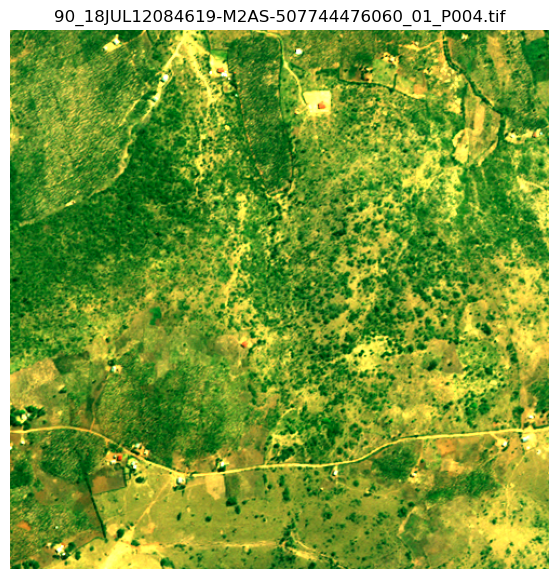

In [49]:
show_chip(chips[14])